<a href="https://colab.research.google.com/github/christy5165/Denoising_Autoencoder.ipynb/blob/main/GAN-2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Starting training...
Epoch 0: Disc Loss 2.1782, Gen Loss 0.8748
Epoch 200: Disc Loss 0.9865, Gen Loss 0.6828
Epoch 400: Disc Loss 1.5323, Gen Loss 0.7395
Epoch 600: Disc Loss 1.4035, Gen Loss 0.9737
Epoch 800: Disc Loss 1.3517, Gen Loss 0.7956
Training Complete!

Example Generated Samples (Targets 5.0):
[[3.2863793]
 [4.4037805]
 [4.018988 ]
 [4.5303144]
 [4.300088 ]]


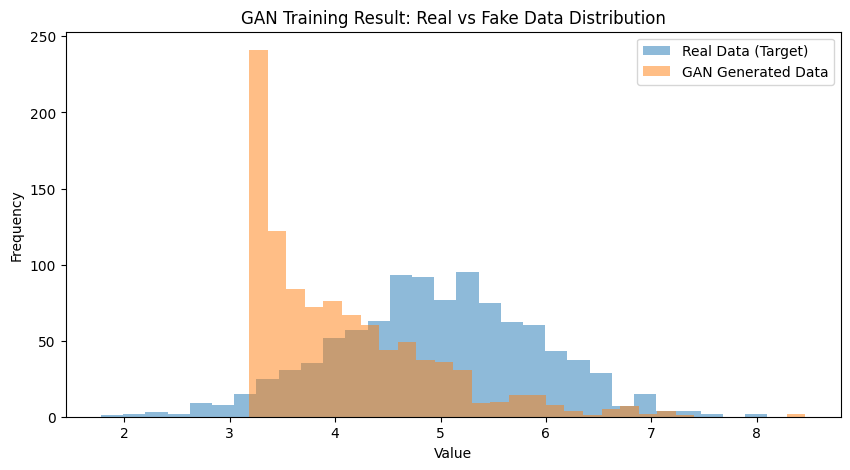

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# 1. SETUP THE DATA
# ---------------------------------------------------------
# Our "Real" data is just a collection of numbers centered around 5.0
def get_real_data(n=1000):
    # Creating a distribution of points (mean=5, std_dev=1)
    return torch.randn(n, 1) + 5.0

# ---------------------------------------------------------
# 2. DEFINE THE MODELS
# ---------------------------------------------------------
# The Generator: Learns to turn random noise into "Real-looking" data
class Generator(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(1, 16),
            nn.ReLU(),
            nn.Linear(16, 1)
        )
    def forward(self, x):
        return self.model(x)

# The Discriminator: Learns to tell if a number is Real or Fake
class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(1, 16),
            nn.ReLU(),
            nn.Linear(16, 1),
            nn.Sigmoid() # Outputs a probability: 0 (Fake) to 1 (Real)
        )
    def forward(self, x):
        return self.model(x)

# Initialize the models
gen = Generator()
disc = Discriminator()

# Loss function and Optimizers
criterion = nn.BCELoss()
gen_opt = optim.Adam(gen.parameters(), lr=0.001)
disc_opt = optim.Adam(disc.parameters(), lr=0.001)

# ---------------------------------------------------------
# 3. TRAINING LOOP
# ---------------------------------------------------------
print("Starting training...")
epochs = 1000
batch_size = 64

for epoch in range(epochs):
    # --- Part A: Train Discriminator ---
    real_data = get_real_data(batch_size)
    noise = torch.randn(batch_size, 1)
    fake_data = gen(noise).detach() # Create fakes but don't train Generator yet

    # Check real data (should be 1) and fake data (should be 0)
    disc_real = disc(real_data)
    disc_fake = disc(fake_data)

    loss_d = criterion(disc_real, torch.ones_like(disc_real)) + \
             criterion(disc_fake, torch.zeros_like(disc_fake))

    disc_opt.zero_grad()
    loss_d.backward()
    disc_opt.step()

    # --- Part B: Train Generator ---
    noise = torch.randn(batch_size, 1)
    fake_data = gen(noise)
    output = disc(fake_data)

    # Generator wants the Discriminator to think the fakes are REAL (1)
    loss_g = criterion(output, torch.ones_like(output))

    gen_opt.zero_grad()
    loss_g.backward()
    gen_opt.step()

    if epoch % 200 == 0:
        print(f"Epoch {epoch}: Disc Loss {loss_d.item():.4f}, Gen Loss {loss_g.item():.4f}")

print("Training Complete!\n")

# ---------------------------------------------------------
# 4. SHOW RESULTS
# ---------------------------------------------------------
# Generate 5 sample points to show the teacher
with torch.no_grad():
    sample_noise = torch.randn(5, 1)
    generated_points = gen(sample_noise)
    print("Example Generated Samples (Targets 5.0):")
    print(generated_points.numpy())

# Plotting the comparison
plt.figure(figsize=(10, 5))
plt.hist(get_real_data(1000).numpy(), bins=30, alpha=0.5, label='Real Data (Target)')
plt.hist(gen(torch.randn(1000, 1)).detach().numpy(), bins=30, alpha=0.5, label='GAN Generated Data')
plt.title("GAN Training Result: Real vs Fake Data Distribution")
plt.xlabel("Value")
plt.ylabel("Frequency")
plt.legend()
plt.show()